In [1]:
import os
import pathlib

import numpy as np
import scipy as sp
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import pingouin as pg
import sklearn 


import STX3KO_analyses as stx
u = stx.utilities

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
np.roll(np.arange(30), -19+5)

array([14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,  0,
        1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])

In [3]:
sess = u.load_single_day(ctrl_mice[0],0)
rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


In [14]:
def train_svc(sess, train_day=5):
    if sess.novel_arm == -1:
        rz_fam = rz_late
        rz_nov = rz_early
    else:
        rz_fam = rz_early
        rz_nov = rz_late
    
    day_mask = sess.trial_info['sess_num']==train_day
    
    day_mat_rr = []
    day_mat_tr = []

    ttype_vec = []
    sess.trial_matrices['F_dff'][np.isnan(sess.trial_matrices['F_dff'])]=0
    for ttype in ('nov', 'fam'):
        if ttype == 'nov':
            ttype_mask = sess.trial_info['LR']==sess.novel_arm
            rz = rz_nov

        else:
            ttype_mask = sess.trial_info['LR']!= sess.novel_arm
            rz = rz_fam

        day_mat = sess.trial_matrices['F_dff'][day_mask*ttype_mask,:,:]
        day_mat_rr.append(np.roll(day_mat, 15-rz[0], axis=1))
        day_mat_tr.append(day_mat)

        ttype_vec.extend([ttype for i in range(day_mat.shape[0])])
    ttype_vec = np.array(ttype_vec)

    day_mat_rr = np.concatenate(day_mat_rr, axis=0)
    day_mat_tr = np.concatenate(day_mat_tr, axis=0)

    pos_rr = np.arange(30)[np.newaxis,:,np.newaxis]*np.ones_like(day_mat_rr)
    pos_tr = np.arange(30)[np.newaxis,:,np.newaxis]*np.ones_like(day_mat_tr)

    prop_fam, prop_nov = (ttype_vec=='fam').sum(), (ttype_vec=='nov').sum()

    train_mat_rr = day_mat_rr.reshape((-1, day_mat_rr.shape[2]))
    train_labels_rr = pos_rr.reshape((-1, pos_rr.shape[-1]))[:,0]
    weights = prop_fam*1.*(ttype_vec=='nov') + prop_nov*1.*(ttype_vec=='fam')
    weights = weights[:,np.newaxis, np.newaxis]*np.ones_like(day_mat_rr)
    weights = weights.reshape((-1, pos_rr.shape[-1]))[:,0]

    train_mat_tr = day_mat_tr.reshape((-1, day_mat_tr.shape[2]))
    train_labels_tr = pos_tr.reshape((-1, pos_tr.shape[-1]))[:,0]

    svc_rr = sklearn.svm.SVC(kernel='linear').fit(train_mat_rr, train_labels_rr, sample_weight=weights.flatten())
    svc_tr = sklearn.svm.SVC(kernel='linear').fit(train_mat_tr, train_labels_tr, sample_weight=weights.flatten())

    return {'svc_tr': svc_tr, 'svc_rr': svc_rr, 
            'tmat_rr': day_mat_rr, 'tmat_tr': day_mat_tr,
            'ttype_vec': np.array(ttype_vec)}


def test_svc(sess, test_day, svc_rr, svc_tr):
    if sess.novel_arm == -1:
        rz_fam = rz_late
        rz_nov = rz_early
    else:
        rz_fam = rz_early
        rz_nov = rz_late
    
    day_mask = sess.trial_info['sess_num']==test_day
    
    day_mat_rr = []
    day_mat_tr = []

    ttype_vec = []
    sess.trial_matrices['F_dff'][np.isnan(sess.trial_matrices['F_dff'])]=0
    for ttype in ('nov', 'fam'):
        if ttype == 'nov':
            ttype_mask = sess.trial_info['LR']==sess.novel_arm
            rz = rz_nov

        else:
            ttype_mask = sess.trial_info['LR']!= sess.novel_arm
            rz = rz_fam

        day_mat = sess.trial_matrices['F_dff'][day_mask*ttype_mask,:,:]
        day_mat_rr.append(np.roll(day_mat, 15-rz[0], axis=1))
        day_mat_tr.append(day_mat)

        ttype_vec.extend([ttype for i in range(day_mat.shape[0])])

    ttype_vec = np.array(ttype_vec)
    day_mat_rr = np.concatenate(day_mat_rr, axis=0)
    day_mat_tr = np.concatenate(day_mat_tr, axis=0)

    # pos_rr = np.arange(30)[np.newaxis,:,np.newaxis]*np.ones_like(day_mat_rr)
    # pos_tr = np.arange(30)[np.newaxis,:,np.newaxis]*np.ones_like(day_mat_tr)

    test_mat_rr = day_mat_rr.reshape((-1, day_mat_rr.shape[2]))
    

    test_mat_tr = day_mat_tr.reshape((-1, day_mat_tr.shape[2]))
    

    pred_labels_rr = svc_rr.predict(test_mat_rr)
    pred_labels_tr = svc_tr.predict(test_mat_tr)

    return {'tmat_rr': day_mat_rr,
            'tmat_tr': day_mat_tr,
            'ttype_vec': ttype_vec,
            'pred_labels_rr': pred_labels_rr.reshape(day_mat_rr.shape[:2]),
            'pred_labels_tr': pred_labels_tr.reshape(day_mat_tr.shape[:2]),
            }

def get_errors(results_dict):
    pos = np.arange(30)/31*2*np.pi-np.pi
    get_err = lambda pred_pos : np.abs(np.angle(np.exp(1j*(pos-pred_pos))))/2/np.pi*30

    pred_pos_rr = results_dict['pred_labels_rr']/31*2*np.pi-np.pi
    err_rr = get_err(pred_pos_rr)

    pred_pos_tr = results_dict['pred_labels_tr']/31*2*np.pi-np.pi
    err_tr = get_err(pred_pos_tr)

    return {'err_rr': err_rr,
            'err_tr': err_tr}

In [15]:
rows = []
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    
    for mouse in mice:
        print(mouse)
        sess = u.single_mouse_concat_sessions(mouse, np.arange(6))

        
        for day in range(5):
            svc_dict = train_svc(sess)
            for next_day in range(day+1,6):
                results_dict = test_svc(sess,0,svc_dict['svc_rr'], svc_dict['svc_tr'])

                err_dict = get_errors(results_dict)

                for ttype in ('fam', 'nov'):

                    err_rr = err_dict['err_rr'][results_dict['ttype_vec']==ttype,:].mean(axis=0)
                    err_tr = err_dict['err_tr'][results_dict['ttype_vec']==ttype,:].mean(axis=0)
                    
                    rows.append({'cond': cond,
                                'mouse': mouse,
                                'day': day,
                                'next_day': next_day,
                                'ttype': ttype,
                                'err_rr': err_rr,
                                'err_tr': err_tr})
svc_df = pd.DataFrame(rows)


4467331.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467331.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467333.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


05_12_2020 YMaze_LNovel
mCherry6
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry7
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry8
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
mCherry9
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


28_09_2020 YMaze_LNovel


...

01_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


02_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


03_10_2020 YMaze_LNovel
4467975.4
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
4467975.5
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
Cre7
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
Cre9
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


In [16]:
svc_df.to_pickle('/home/mplitt/shuffle_pkls/svc_forward_df_dff.pkl')

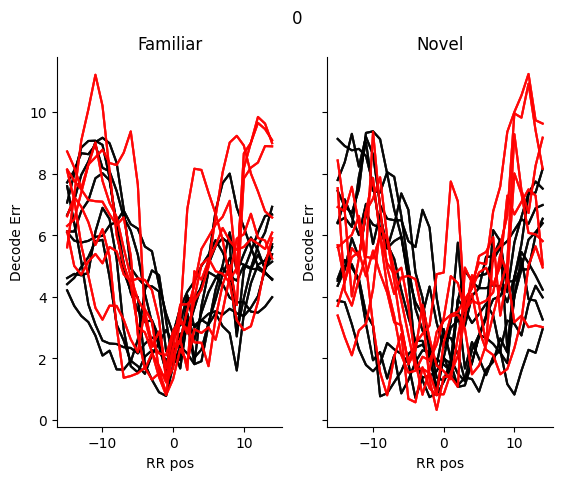

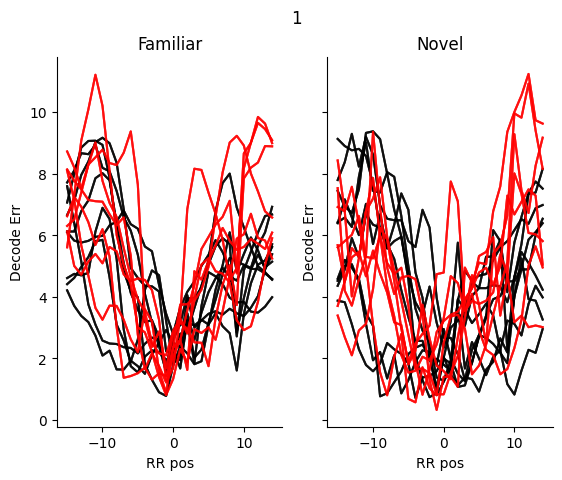

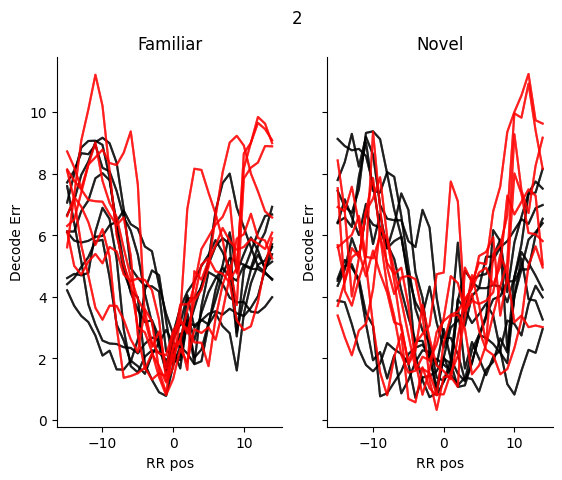

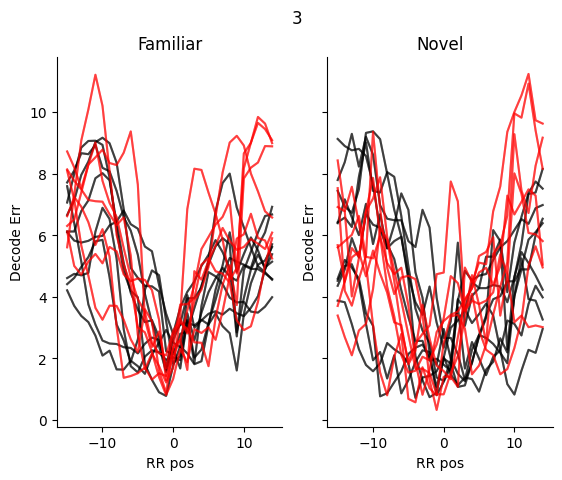

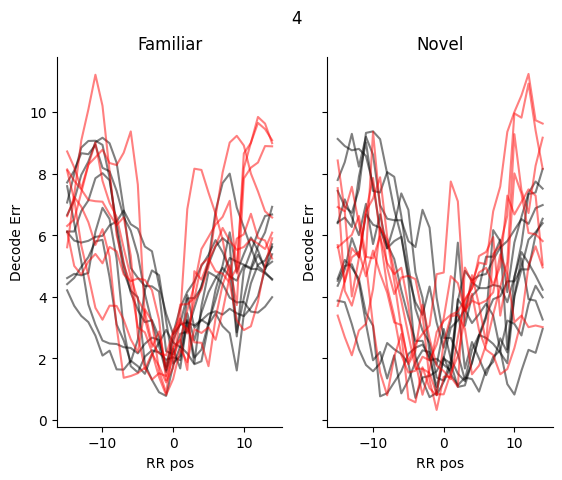

In [17]:
bins = np.arange(-15,15)
for day in range(5):
    fig, ax = plt.subplots(1,2, sharey=True)
    fig.suptitle(day)

    for cond, color in zip(('ctrl', 'ko'), ('black', 'red')):
        tmp_df = svc_df.loc[(svc_df['cond']==cond) * (svc_df['day']==day)]
        for i, ttype in enumerate(('fam', 'nov')):
            _tmp_df = tmp_df.loc[tmp_df['ttype']==ttype]
            arr = np.vstack(_tmp_df['err_rr'].values)
            mu, sem = arr.mean(axis=0), sp.stats.sem(arr,axis=0)
            ax[i].plot(bins, arr.T,color=color, alpha=.5)
            # ax[i].plot(bins, mu, color=color)
            # ax[i].fill_between(bins, mu-sem, mu+sem, color=color, alpha=.4)
    
    ax[0].set_title('Familiar')
    ax[1].set_title('Novel')
    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        a.set_xlabel('RR pos')
        a.set_ylabel('Decode Err')

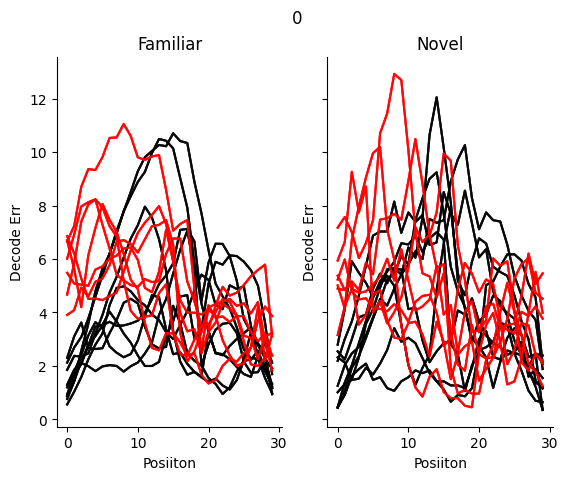

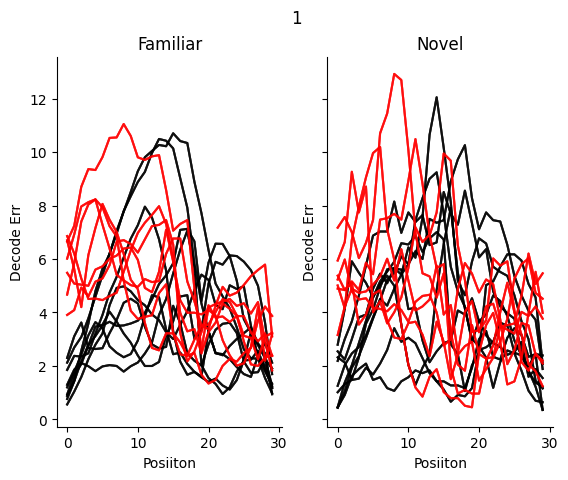

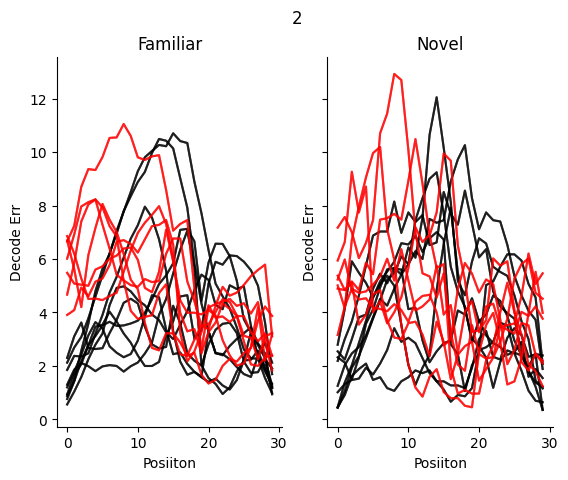

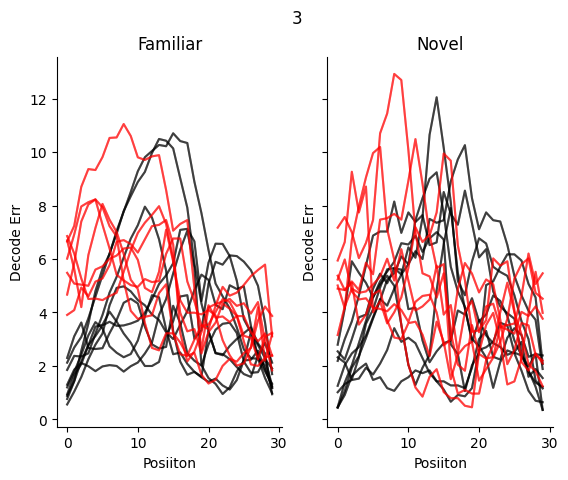

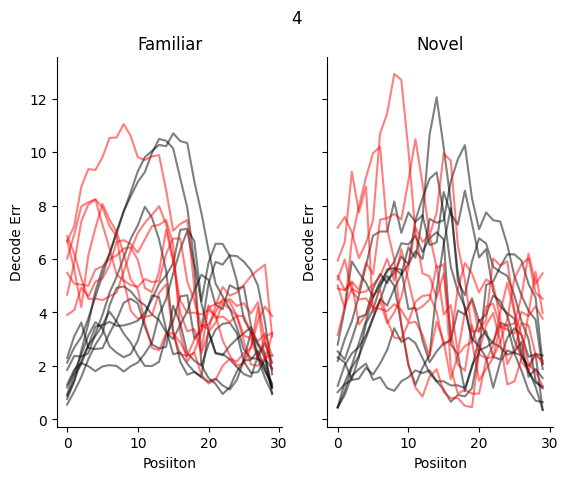

In [22]:
bins = np.arange(30)
for day in range(5):
    fig, ax = plt.subplots(1,2, sharey=True)
    fig.suptitle(day)

    for cond, color in zip(('ctrl', 'ko'), ('black', 'red')):
        tmp_df = svc_df.loc[(svc_df['cond']==cond) * (svc_df['day']==day)]
        for i, ttype in enumerate(('fam', 'nov')):
            _tmp_df = tmp_df.loc[tmp_df['ttype']==ttype]
            arr = np.vstack(_tmp_df['err_tr'].values)
            mu, sem = arr.mean(axis=0), sp.stats.sem(arr,axis=0)
            ax[i].plot(bins, arr.T, color=color, alpha=.5)
            # ax[i].plot(bins, mu, color=color)
            # ax[i].fill_between(bins, mu-sem, mu+sem, color=color, alpha=.4)
    
    ax[0].set_title('Familiar')
    ax[1].set_title('Novel')
    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        a.set_xlabel('Posiiton')
        a.set_ylabel('Decode Err')

In [23]:
mu_err_rr, mu_err_tr = [], []
mask = np.abs(np.arange(-15,15))>5
for _, row in svc_df.iterrows():
    mu_err_rr.append(row['err_rr'][mask].mean())
    mu_err_tr.append(row['err_tr'][mask].mean())
svc_df['mu_err_rr'] = mu_err_rr
svc_df['mu_err_tr'] = mu_err_tr


<Axes: xlabel='ttype', ylabel='mu_err_rr'>

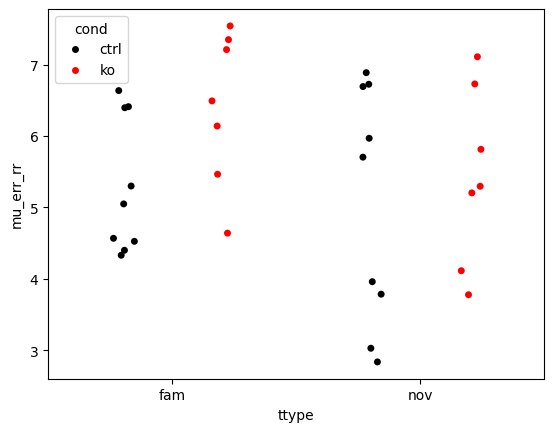

In [24]:
fig, ax= plt.subplots()

tmp_df = svc_df.groupby(['cond', 'mouse','ttype'])['mu_err_rr'].mean().reset_index()
sns.stripplot(data = tmp_df,
              x='ttype',
              y='mu_err_rr',
              hue='cond',
              hue_order=['ctrl', 'ko'],
              palette=['black','red'],
              ax=ax, dodge=True)

<Axes: xlabel='ttype', ylabel='mu_err_tr'>

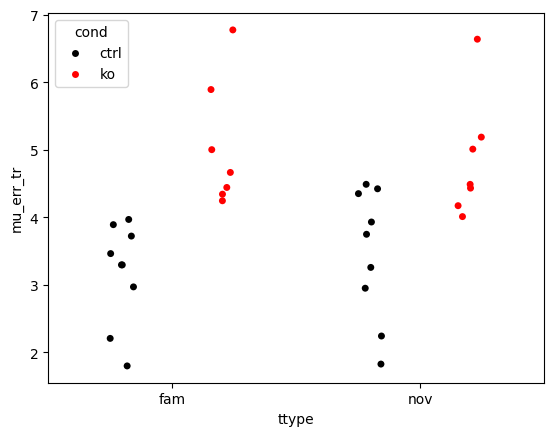

In [25]:
fig, ax= plt.subplots()

tmp_df = svc_df.groupby(['cond', 'mouse','ttype'])['mu_err_tr'].mean().reset_index()
sns.stripplot(data = tmp_df,
              x='ttype',
              y='mu_err_tr',
              hue='cond',
              hue_order=['ctrl', 'ko'],
              palette=['black','red'],
              ax=ax, dodge=True)

In [26]:
test_res = svc.predict(test_mat)
cm = sklearn.metrics.confusion_matrix(test_labels[:,0], test_res)
fig, ax = plt.subplots()
ax.imshow(cm) #/cm.sum(axis=1, keepdims=True))

NameError: name 'svc' is not defined

In [19]:
train_res = train_res.reshape(day_mat_rr.shape[:2])

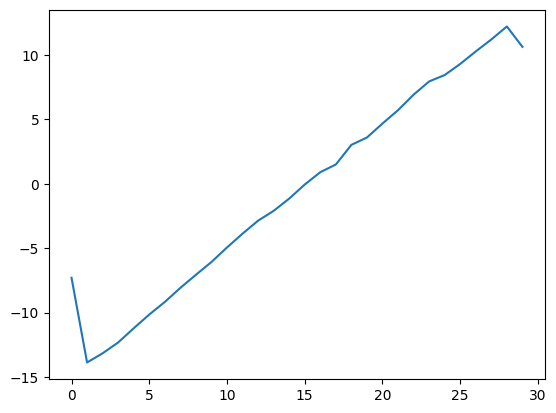

In [22]:
fig, ax = plt.subplots()
mu, sem = train_res.mean(axis=0), sp.stats.sem(train_res, axis=0)

ax.plot(mu)

In [ ]:
# get mean within a day
yhat_dict= {}
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    yhat_dict[cond] = {}
    for mouse in mice:
        sess = u.single_mouse_concat_sessions(mouse, np.arange(6))
        yhat_dict[cond][mouse] = {}

        if sess.novel_arm == -1:
            rz_fam = rz_late
            rz_nov = rz_early
        else:
            rz_fam = rz_early
            rz_nov = rz_late
        
            


        for ttype in ('fam', 'nov'):
            yhat_dict[cond][mouse][ttype] = {}
            if ttype == 'nov':
                ttype_mask = sess.trial_info['LR']==sess.novel_arm
                rz = rz_nov
                rz_other = rz_fam
            else:
                ttype_mask = sess.trial_info['LR']!= sess.novel_arm
                rz = rz_fam
                rz_other = rz_nov


            for day in range(5):
                yhat_dict[cond][mouse][ttype][day] = {}
                day_mask = sess.trial_info['sess_num'] == day
                day_mat = sess.trial_matrices['F_dff'][ttype_mask*day_mask,:,:]      
                day_mat-= np.nanmin(day_mat,axis=-1,keepdims=True)
                day_mat_mu = np.nanmean(day_mat, axis=0)
                day_mat_mu[np.isnan(day_mat_mu)]=1E-3
                day_mat_mu = np.roll(day_mat_mu, 15 - rz[0], axis=0)

                for next_day in range(day+1,6):
                    yhat_dict[cond][mouse][ttype][day][next_day] = {}
                    for same_arm in  (True, False):
                        if same_arm:
                            _ttype_mask = ttype_mask
                            _rz = rz
                        else:
                            _ttype_mask = ~ttype_mask
                            _rz = rz_other
                        next_day_mask = sess.trial_info['sess_num'] == next_day
                        next_day_mat = sess.trial_matrices['F_dff'][_ttype_mask*next_day_mask, :, :]
                        next_day_mat -= np.nanmin(next_day_mat, axis=-1, keepdims=True)
                        next_day_mat[np.isnan(next_day_mat)]=1E-3
                        next_day_mat = np.roll(next_day_mat, 15-_rz[0], axis=1)

                        yhat = np.zeros(next_day_mat.shape[:2])
                        for trial in range(next_day_mat.shape[0]):
                            y = next_day_mat[trial,:,:]
                            yhat[trial,:] = np.argmax(stx.naive_bayes.test(y, day_mat_mu, poisson=True),axis=-1)

                        yhat_dict[cond][mouse][ttype][day][next_day][same_arm] = yhat
                    # yhat_dict[cond][mouse][ttype][day][next_day] = yhat


29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel


/tmp/ipykernel_331132/1098843843.py:35: RuntimeWarning: All-NaN slice encountered
  day_mat-= np.nanmin(day_mat,axis=-1,keepdims=True)
/tmp/ipykernel_331132/1098843843.py:51: RuntimeWarning: All-NaN slice encountered
  next_day_mat -= np.nanmin(next_day_mat, axis=-1, keepdims=True)


29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel


/tmp/ipykernel_331132/1098843843.py:35: RuntimeWarning: All-NaN slice encountered
  day_mat-= np.nanmin(day_mat,axis=-1,keepdims=True)
/tmp/ipykernel_331132/1098843843.py:51: RuntimeWarning: All-NaN slice encountered
  next_day_mat -= np.nanmin(next_day_mat, axis=-1, keepdims=True)


29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel


...

/tmp/ipykernel_331132/1098843843.py:35: RuntimeWarning: All-NaN slice encountered
  day_mat-= np.nanmin(day_mat,axis=-1,keepdims=True)
/tmp/ipykernel_331132/1098843843.py:51: RuntimeWarning: All-NaN slice encountered
  next_day_mat -= np.nanmin(next_day_mat, axis=-1, keepdims=True)


18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


/tmp/ipykernel_331132/1098843843.py:35: RuntimeWarning: All-NaN slice encountered
  day_mat-= np.nanmin(day_mat,axis=-1,keepdims=True)
/tmp/ipykernel_331132/1098843843.py:51: RuntimeWarning: All-NaN slice encountered
  next_day_mat -= np.nanmin(next_day_mat, axis=-1, keepdims=True)


18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


/tmp/ipykernel_331132/1098843843.py:35: RuntimeWarning: All-NaN slice encountered
  day_mat-= np.nanmin(day_mat,axis=-1,keepdims=True)
/tmp/ipykernel_331132/1098843843.py:51: RuntimeWarning: All-NaN slice encountered
  next_day_mat -= np.nanmin(next_day_mat, axis=-1, keepdims=True)


In [33]:
rows = []
bins = np.linspace(-np.pi, np.pi, num=30)
# bins = np.arange(-6,24)
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        if cond == 'ctrl':
            nov_arm = stx.ymaze_sess_deets.CTRL_sessions[mouse][0]['novel_arm']
        else:
            nov_arm = stx.ymaze_sess_deets.KO_sessions[mouse][0]['novel_arm']
       
        for ttype in ('fam', 'nov'):

            # if ttype == 'nov':
            #     rz = rz_nov
            # else:
            #     rz = rz_fam

            for day in range(5):
                for next_day in range(day+1, 6):
                    for same_arm in (True, False):
                        diff = np.nanmean(bins - yhat_dict[cond][mouse][ttype][day][next_day][same_arm],axis=0)
                        rows.append({'cond': cond,
                                    'mouse': mouse,
                                    'ttype': ttype,
                                    'day': day,
                                    'next_day': next_day,
                                    'same_arm': same_arm,
                                    #  'rzone': rz,
                                    'yhat_err': np.abs(np.angle(np.exp(1j*diff)))})
yhat_df = pd.DataFrame(rows)


In [60]:

rz_err = []
for i, row in yhat_df.iterrows():
    rz_err.append(row['yhat_err'][9:14].mean())
yhat_df['rz_err'] = rz_err

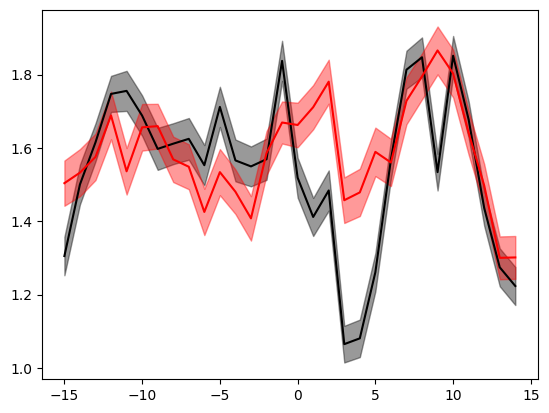

In [61]:
fig, ax = plt.subplots( sharex=True, sharey=True)
day = 1
next_day = 4

bins = np.arange(30)
rz_bins = np.arange(-15,15)
for i, (cond, color) in enumerate(zip(('ctrl', 'ko'), ('black','red'))):

    mask = (yhat_df['cond']==cond) * (yhat_df['same_arm']==False)
    tmp_df = yhat_df.loc[mask]
    
    arr = np.vstack(tmp_df['yhat_err'].values)
    mu, sem = arr.mean(axis=0), sp.stats.sem(arr,axis=0)
    ax.plot(rz_bins,mu, color=color)
    ax.fill_between(rz_bins, mu-sem, mu+sem, color=color, alpha=.4)
# ax.set_xlim([-10,2])


<Axes: xlabel='ttype', ylabel='rz_err'>

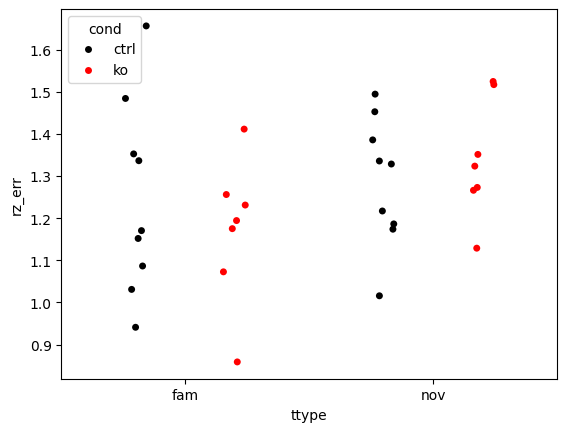

In [63]:
fig, ax = plt.subplots()

tmp_df = yhat_df.loc[yhat_df['day']>-1].groupby(['cond', 'mouse', 'ttype', 'same_arm'])['rz_err'].mean().reset_index()
sns.stripplot(data = tmp_df.loc[tmp_df['same_arm']==True],
              x='ttype',
              y='rz_err',
              hue='cond',
              hue_order=('ctrl', 'ko'),
              palette = ('black','red'),
              dodge=True, ax=ax)

In [59]:
res = pg.pairwise_tests(data = tmp_df.loc[tmp_df['same_arm']==False], dv='rz_err',
                        within='ttype', between='cond', subject='mouse',
                        parametric=False)
res

,Contrast,ttype,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,hedges
0,ttype,-,fam,nov,True,False,NaN,46.0,two-sided,0.274445,0.481924
1,cond,-,ctrl,ko,False,False,29.0,NaN,two-sided,0.837063,0.147022
2,ttype * cond,fam,ctrl,ko,False,False,57.0,NaN,two-sided,0.005245,1.417900
3,ttype * cond,nov,ctrl,ko,False,False,12.0,NaN,two-sided,0.041783,-0.786390


In [7]:
# look at error as a function of distance to reward 

In [ ]:
# error near rewards vs error at other locations